In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('./data/IndianWeatherRepository.csv')

In [5]:
cloud_by_condition = df.groupby('condition_text')['cloud'].mean().sort_values()
print(cloud_by_condition)

condition_text
Clear                                            5.158948
Clear                                            5.794116
Sunny                                           13.044041
Mist                                            33.751054
Partly Cloudy                                   37.583333
Partly Cloudy                                   39.035813
Partly cloudy                                   39.379169
Thundery outbreaks possible                     53.493671
Thundery outbreaks in nearby                    58.363636
Fog                                             59.816559
Overcast                                        62.455567
Patchy snow possible                            65.600000
Patchy heavy snow                               67.333333
Patchy light snow in area with thunder          67.750000
Heavy rain at times                             68.250000
Patchy light drizzle                            68.953191
Patchy light rain                               70.155405

<Axes: xlabel='condition_text'>

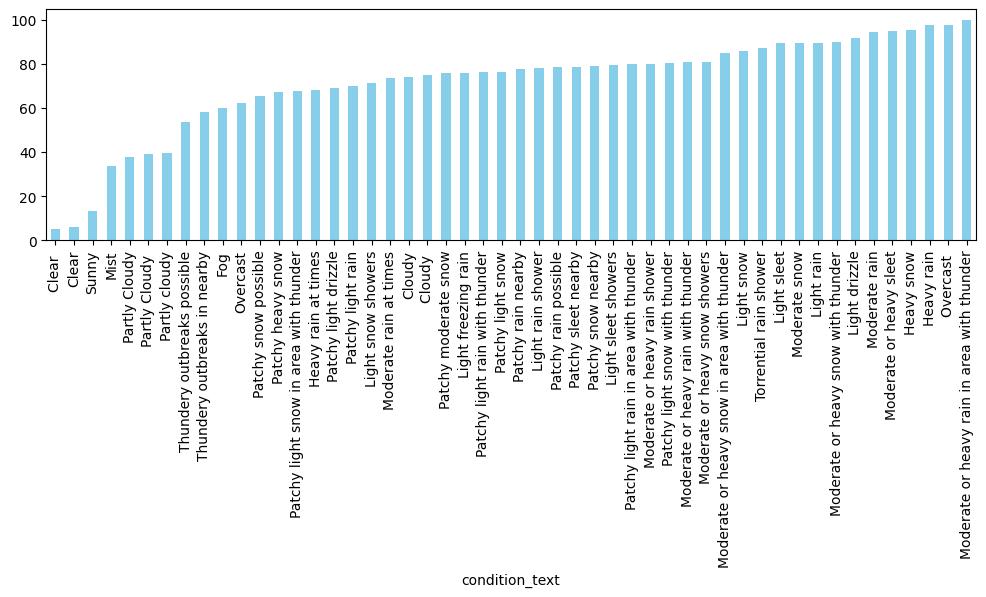

In [6]:
plt.figure(figsize=(12, 3))
cloud_by_condition.plot(kind='bar', color='skyblue')

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/IndianWeatherRepository.csv")

df['last_updated'] = pd.to_datetime(df['last_updated'])

df = df.sort_values('last_updated')

In [20]:
features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'wind_kph',
    'precip_mm',
    'visibility_km',
    'uv_index',
    'gust_kph',
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'moon_illumination'
]

target = "cloud"

In [21]:
locations = sorted(df["location_name"].unique())

location_to_id = {
    loc: idx
    for idx, loc in enumerate(locations)
}

df["node_id"] = df["location_name"].map(location_to_id)

num_nodes = len(locations)

print("Number of nodes:", num_nodes)

Number of nodes: 552


In [22]:
coord_df = (
    df.groupby("location_name")
      .first()[["latitude", "longitude"]]
      .reset_index()
)

coord_df["node_id"] = coord_df["location_name"].map(location_to_id)

coord_df = coord_df.sort_values("node_id")

coords = coord_df[["latitude", "longitude"]].values

print(coords.shape)

(552, 2)


In [23]:
from scipy.spatial import distance_matrix

K = 5

D = distance_matrix(coords, coords)

edge_list = []

for i in range(num_nodes):

    nearest = np.argsort(D[i])[1:K+1]

    for j in nearest:

        edge_list.append([i, j])
        edge_list.append([j, i])   # make graph undirected

In [24]:
import torch

edge_index = torch.tensor(
    edge_list,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

print("Max node index:", edge_index.max().item())
print("Min node index:", edge_index.min().item())

assert edge_index.max().item() < num_nodes
assert edge_index.min().item() >= 0

torch.Size([2, 5520])
Max node index: 551
Min node index: 0


In [13]:
import torch.nn.functional as F

from torch_geometric.nn import GCNConv

class CloudGCN(torch.nn.Module):

    def __init__(self, num_features):

        super().__init__()

        self.conv1 = GCNConv(
            num_features,
            64
        )

        self.conv2 = GCNConv(
            64,
            32
        )

        self.fc = torch.nn.Linear(
            32,
            1
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.fc(x)

        return x.squeeze()

In [25]:
import torch

edge_index = torch.tensor(
    edge_list,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

print("Max node index:", edge_index.max().item())
print("Min node index:", edge_index.min().item())

assert edge_index.max().item() < num_nodes
assert edge_index.min().item() >= 0

torch.Size([2, 5520])
Max node index: 551
Min node index: 0


In [26]:
from torch_geometric.data import Data

timestamps = sorted(df["last_updated"].unique())

graphs = []

for i in range(len(timestamps) - 1):

    current_time = timestamps[i]
    next_time = timestamps[i + 1]

    current_df = df[df["last_updated"] == current_time]
    next_df = df[df["last_updated"] == next_time]

    x = np.zeros(
        (num_nodes, len(features)),
        dtype=np.float32
    )

    y = np.zeros(
        num_nodes,
        dtype=np.float32
    )

    # current timestamp features
    for _, row in current_df.iterrows():

        nid = int(row["node_id"])

        x[nid] = row[features].values

    # next timestamp cloud target
    for _, row in next_df.iterrows():

        nid = int(row["node_id"])

        y[nid] = row[target]

    graph = Data(
        x=torch.tensor(x),
        edge_index=edge_index,
        y=torch.tensor(y)
    )

    graphs.append(graph)

print("Graphs created:", len(graphs))

Graphs created: 867


In [27]:
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv

class CloudGCN(nn.Module):

    def __init__(self, num_features):

        super().__init__()

        self.conv1 = GCNConv(num_features, 64)

        self.conv2 = GCNConv(64, 32)

        self.fc = nn.Linear(32, 1)

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.fc(x)

        return x.squeeze()

In [28]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CloudGCN(
    num_features=len(features)
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

criterion = nn.MSELoss()

In [29]:
epochs = 50

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for graph in graphs:

        graph = graph.to(device)

        optimizer.zero_grad()

        pred = model(graph)

        loss = criterion(
            pred,
            graph.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(graphs)

    print(
        f"Epoch {epoch+1:03d} | Loss: {avg_loss:.4f}"
    )

Epoch 001 | Loss: 352.4244
Epoch 002 | Loss: 331.2279
Epoch 003 | Loss: 324.5635
Epoch 004 | Loss: 323.2731
Epoch 005 | Loss: 322.4823
Epoch 006 | Loss: 322.6651
Epoch 007 | Loss: 321.5328
Epoch 008 | Loss: 320.9324
Epoch 009 | Loss: 320.3297
Epoch 010 | Loss: 319.4706
Epoch 011 | Loss: 319.0230
Epoch 012 | Loss: 318.8530
Epoch 013 | Loss: 317.8119
Epoch 014 | Loss: 316.1980
Epoch 015 | Loss: 315.9094
Epoch 016 | Loss: 315.9113
Epoch 017 | Loss: 314.7713
Epoch 018 | Loss: 314.0925
Epoch 019 | Loss: 313.3538
Epoch 020 | Loss: 313.5872
Epoch 021 | Loss: 314.0633
Epoch 022 | Loss: 312.5870
Epoch 023 | Loss: 312.5408
Epoch 024 | Loss: 312.2481
Epoch 025 | Loss: 312.1961
Epoch 026 | Loss: 311.8496
Epoch 027 | Loss: 311.9073
Epoch 028 | Loss: 312.0030
Epoch 029 | Loss: 312.3853
Epoch 030 | Loss: 311.5305
Epoch 031 | Loss: 311.3597
Epoch 032 | Loss: 311.4029
Epoch 033 | Loss: 310.8328
Epoch 034 | Loss: 310.8139
Epoch 035 | Loss: 310.6140
Epoch 036 | Loss: 310.4974
Epoch 037 | Loss: 310.3467
E

In [30]:
df.groupby("last_updated").size().describe()

count    868.000000
mean     136.288018
std      181.022127
min        1.000000
25%        1.000000
50%        2.000000
75%      264.500000
max      548.000000
dtype: float64

In [31]:
location_counts = (
    df.groupby("location_name")
      .size()
)

print(location_counts.describe())

print(location_counts.sort_values(ascending=False).head(20))

count    552.000000
mean     214.307971
std       30.234163
min        5.000000
25%      215.000000
50%      216.000000
75%      216.000000
max      456.000000
dtype: float64
location_name
Nagar            456
Udaipur          422
East Godavari    369
Siang            355
Barddhaman       310
Kolkata          271
Dharmanagar      269
Haora            245
Mumbai           242
Bastar           238
Bangalore        238
Puri District    236
Kantha           229
South Salmara    225
Goa              225
Kanpur           223
Nandi Hills      222
Medinipur        221
Imphal           221
North Gauhati    218
dtype: int64


In [32]:
df[['location_name','last_updated']].head(20)

,location_name,last_updated
73,Kupwara,2023-08-29 10:15:00
0,Ashoknagar,2023-08-29 10:45:00
371,Koraput,2023-08-29 10:45:00
370,Anugul,2023-08-29 10:45:00
369,Puri,2023-08-29 10:45:00
368,Nagpur,2023-08-29 10:45:00
367,Mumbai,2023-08-29 10:45:00
366,Palghar,2023-08-29 10:45:00
365,Thane,2023-08-29 10:45:00
364,Jalna,2023-08-29 10:45:00
